In [93]:
import numpy as np
from scipy.interpolate import RegularGridInterpolator
from scipy.constants import Stefan_Boltzmann as sigma
from scipy.constants import Boltzmann as k_B
from scipy.constants import c
from scipy.constants import atomic_mass as m_u
from scipy.constants import G
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import PatchCollection

In [94]:
#  Table reader function

def read_log_table(filename):
    """
    Read table from a file:

    Returns
    -------
    log_T_vals : (n_T,) array
    log_R_vals : (n_R,) array
    log_values : (n_T, n_R) array
    """
    with open(filename, "r") as f:
        lines = f.readlines()
    log_R_vals = None
    log_T_vals = []
    rows = []

    for line in lines:
        s = line.strip()
        if not s:
            continue

        if s.startswith("logT"):
            parts = s.split()
            log_R_vals = np.array([float(x) for x in parts[1:]], dtype=float) # parts[0] = 'logT', parts[1:] = log10(R) values
            continue

        if log_R_vals is None: # Skip everything until header is found
            continue

        parts = s.split()
        
        if len(parts) != len(log_R_vals) + 1: # first is (logT), rest are len(log_R_vals) numeric entries
            continue

        try:
            vals = [float(x) for x in parts]
        except ValueError:
            continue

        log_T_vals.append(vals[0])
        rows.append(vals[1:])
    log_T_vals = np.array(log_T_vals, dtype=float)
    log_values = np.array(rows, dtype=float)

    return log_T_vals, log_R_vals, log_values



logT_opac, logR_opac, log_kappa_table = read_log_table("opacity.txt") # Opacity: log10(kappa) [cm^2/g]
logT_eps, logR_eps, log_eps_table = read_log_table("epsilon.txt") # Epsilon: log10(epsilon) [cgs] (erg g^-1 s^-1)

opacity_interp_log = RegularGridInterpolator((logT_opac, logR_opac),log_kappa_table,method="linear",bounds_error=False,fill_value=None)                                             
epsilon_interp_log = RegularGridInterpolator((logT_eps, logR_eps),log_eps_table,method="linear",bounds_error=False,fill_value=None)  
                                             

def log10_R_from_T_rho(T, rho):
    rho_cgs = rho * 1e-3          # g/cm^3
    R = rho_cgs / (T / 1e6)**3
    return np.log10(R)



def get_opacity(T, rho):
    log10_T = np.log10(T)
    log10_R = log10_R_from_T_rho(T, rho)

    if log10_T < logT_opac[0] or log10_T > logT_opac[-1]:
        print(
            f"WARNING [opacity]: log10(T)={log10_T:.3f} outside "
            f"[{logT_opac[0]}, {logT_opac[-1]}]. Extrapolating."
        )
    if log10_R < logR_opac[0] or log10_R > logR_opac[-1]:
        print(
            f"WARNING [opacity]: log10(R)={log10_R:.3f} outside "
            f"[{logR_opac[0]}, {logR_opac[-1]}]. Extrapolating."
        )

    # Interpolate log10(kappa_cgs) where kappa_cgs is in [cm^2/g]
    log10_kappa_cgs = opacity_interp_log([[log10_T, log10_R]])[0]

    # Convert cm^2/g -> m^2/kg
    # 1 cm^2/g = (1e-4 m^2)/(1e-3 kg) = 0.1 m^2/kg
    kappa_si = (10.0 ** log10_kappa_cgs) * 0.1
    return kappa_si


def get_epsilon(T, rho):
    log10_T = np.log10(T)
    log10_R = log10_R_from_T_rho(T, rho)

    if log10_T < logT_eps[0] or log10_T > logT_eps[-1]:
        print(
            f"WARNING [epsilon]: log10(T)={log10_T:.3f} outside "
            f"[{logT_eps[0]}, {logT_eps[-1]}]. Extrapolating."
        )
    if log10_R < logR_eps[0] or log10_R > logR_eps[-1]:
        print(
            f"WARNING [epsilon]: log10(R)={log10_R:.3f} outside "
            f"[{logR_eps[0]}, {logR_eps[-1]}]. Extrapolating."
        )

    # Interpolate log10(epsilon_cgs) where epsilon_cgs is in [erg g^-1 s^-1]
    log10_eps_cgs = epsilon_interp_log([[log10_T, log10_R]])[0]

    # Convert erg g^-1 s^-1 -> J kg^-1 s^-1
    # 1 erg = 1e-7 J, 1 g = 1e-3 kg -> 1 erg/g/s = 1e-4 J/kg/s
    epsilon_si = (10.0 ** log10_eps_cgs) * 1e-4
    return epsilon_si


if __name__ == "__main__":
    print("Opacity table shape:", log_kappa_table.shape)
    print("   log10(T):", logT_opac[0], "→", logT_opac[-1])
    print("   log10(R):", logR_opac[0], "→", logR_opac[-1])

    print("Epsilon table shape:", log_eps_table.shape)
    print("   log10(T):", logT_eps[0], "→", logT_eps[-1])
    print("   log10(R):", logR_eps[0], "→", logR_eps[-1])


    # solar surface values
    rho_bar = 1.408e3  # kg/m^3
    T0 = 5770.0
    rho0 = 1.42e-7 * rho_bar

    print("\nExample at solar surface:")
    print("T0  =", T0, "K")
    print("rho0=", rho0, "kg/m^3")
    print("kappa =", get_opacity(T0, rho0), "m^2/kg")
    print("epsilon =", get_epsilon(T0, rho0), "J/(kg s)")

Opacity table shape: (70, 19)
   log10(T): 3.75 → 8.7
   log10(R): -8.0 → 1.0
Epsilon table shape: (70, 27)
   log10(T): 3.75 → 8.7
   log10(R): -8.0 → 5.0

Example at solar surface:
T0  = 5770.0 K
rho0= 0.000199936 kg/m^3
kappa = 0.021773387990153128 m^2/kg
epsilon = 5.5360946712825695e-86 J/(kg s)


In [95]:
print(log_kappa_table)

[[-0.77  -0.931 -1.123 ... -0.797 -0.462 -0.093]
 [-0.564 -0.602 -0.679 ... -0.243  0.023  0.311]
 [-0.539 -0.535 -0.531 ...  0.344  0.575  0.822]
 ...
 [-0.633 -0.633 -0.633 ...  0.     0.     0.   ]
 [-0.704 -0.704 -0.704 ...  0.     0.     0.   ]
 [-0.582 -0.753 -0.785 ...  0.     0.     0.   ]]


In [96]:
x = 0.7
y = 0.29+ 1e-10
z = 1- (x+y)
mu = 1/ (2*x + 3*y/4 + z/2)

def P_of_rho_T(rho, T, mu):
    P_rad = (4 * sigma / (3 * c)) * T**4
    P_gas = (rho * k_B * T) / (mu * m_u)
    return P_rad + P_gas

def rho_of_P_T(P, T, mu):
    P_rad = (4 * sigma / (3 * c)) * T**4
    P_gas = P - P_rad
    return P_gas * (mu * m_u) / (k_B * T)

In [97]:
def rhs(m, y):
    """
    RHS of the structure equations.

    Parameters
    ----------
    m :  Mass coordinate [kg]
    y : array of[r, P, L, T]

    Returns
    -------
    dy_dm : array of [dr/dm, dP/dm, dL/dm, dT/dm]
    """
    r, P, L, T = y

    eps = 1e-30
    r_safe = max(r, eps) # to avoid r=0 at center

    rho = rho_of_P_T(P, T, mu) # Density from EOS
    kappa = get_opacity(T, rho)      # [m^2/kg]
    epsilon = get_epsilon(T, rho)    # [J / (kg s)]

    dr_dm = 1.0 / (4.0 * np.pi * r_safe**2 * rho)
    dP_dm = -G * m / (4.0 * np.pi * r_safe**4)
    dL_dm = epsilon
    dT_dm = -3.0 * kappa * L / (256.0 * np.pi**2 * sigma * r_safe**4 * T**3) # radiative gradient only

    return np.array([dr_dm, dP_dm, dL_dm, dT_dm])


In [98]:
# Integrate star with RK4

def integrate_structure(M0,R0,L0,T0,rho0,mu,m_min_fraction=1e-4,r_stop=1e3,rtol=1e-4,atol=1e-8):
    """
    Integrate the stellar structure equations from the surface inward.

    Parameters
    ----------
    M0, R0, L0, T0, rho0, mu: Surface mass, radius, luminosity, Surface tempm, density, Mean molecular weight  [kg, m, W, K, kg/m^3, dimensionless]

    m_min_fraction : Integrate down to m = m_min_fraction * M0.
    r_stop : Stop integration when radius reaches r_stop [m].
    rtol, atol : Relative and absolute tolerances for solve_ivp.

    Returns
    -------
    m_arr, r_arr, P_arr, L_arr, T_arr, rho_arr: arrayt of Mass coordinate, radius, pressure, luminosity, temperature, density 
    """


    P0 = P_of_rho_T(rho0, T0, mu) # initial pressure
    y0 = np.array([R0, P0, L0, T0], dtype=float)
    m_min = m_min_fraction * M0


    def event_r_small(m, y):    # stop when radius becomes small (approach centre)
        r = y[0]
        return r - r_stop
    event_r_small.terminal = True
    event_r_small.direction = -1  # trigger when r is decreasing through r_stop


    def event_nonphysical(m, y): #stop if P or T become zero/negative
        r, P, L, T = y
        return min(P, T, r) - 0.0
    event_nonphysical.terminal = True
    event_nonphysical.direction = -1



    # Integrate inward (m decreases from M0 to m_min)

    # we have to use m as t bcoz-: Interval of integration (t0, tf). The solver starts with t=t0 and integrates until it reaches t=tf

    sol = solve_ivp(fun=rhs,t_span=(M0, m_min),y0=y0,method="RK45",rtol=rtol,atol=atol,events=[event_r_small, event_nonphysical],dense_output=False)

    m_arr = sol.t                   # mass grid (from surface inward)
    r_arr, P_arr, L_arr, T_arr = sol.y
    rho_arr = rho_of_P_T(P_arr, T_arr, mu)

    return m_arr, r_arr, P_arr, L_arr, T_arr, rho_arr

In [99]:
# star with solar surface conditions

if __name__ == "__main__":

    M_sun = 1.98847e30  # kg
    R_sun = 6.957e8     # m
    L_sun = 3.828e26    # W

    rho_bar = 1.408e3   # kg/m^3 (mean solar density)
    rho0 = 1.42e-7 * rho_bar
    T0 = 5770.0         # K

    M0 = M_sun
    R0 = R_sun
    L0 = L_sun

    m_arr, r_arr, P_arr, L_arr, T_arr, rho_arr = integrate_structure(M0=M0,R0=R0,L0=L0,T0=T0,rho0=rho0,mu=mu,m_min_fraction=1e-6,r_stop=1e2)     # stop when r is 100 m
    

    print("Integration finished.")
    print("Number of points:", len(m_arr))
    print("Centre-like values (last point):")
    print("m   =", m_arr[-1], "kg")
    print("r   =", r_arr[-1], "m")
    print("P   =", P_arr[-1], "Pa")
    print("L   =", L_arr[-1], "W")
    print("T   =", T_arr[-1], "K")
    print("rho =", rho_arr[-1], "kg/m^3")

WARNING [opacity]: log10(T)=3.588 outside [3.75, 8.7]. Extrapolating.
WARNING [epsilon]: log10(T)=3.588 outside [3.75, 8.7]. Extrapolating.
WARNING [opacity]: log10(T)=3.533 outside [3.75, 8.7]. Extrapolating.
WARNING [opacity]: log10(R)=1.169 outside [-8.0, 1.0]. Extrapolating.
WARNING [epsilon]: log10(T)=3.533 outside [3.75, 8.7]. Extrapolating.
Integration finished.
Number of points: 74
Centre-like values (last point):
m   = 1.98847e+24 kg
r   = 47344942.1789023 m
P   = 2.0523433790936636e+16 Pa
L   = 3.023236623214813e+25 W
T   = 13939382.368765516 K
rho = 109090.28430991802 kg/m^3


In [100]:
# task 5


def pressure_scale_height(P, rho, g, T):
    return k_B * T / (mu * m_u * g)

# def cp_ideal():
#     return 5.0 * k_B / (2.0 * mu * m_u)

def cp_ideal(mu_local=None):
    """C_p for ideal gas."""
    mu_use = mu if mu_local is None else mu_local
    return 5.0 * k_B / (2.0 * mu_use * m_u)

def nabla_stable(kappa, rho, H_p, L, r, T):
    """Radiative temperature gradient"""
    return 3.0 * kappa * rho * H_p * L / (64.0 * np.pi * r**2 * sigma * T**4)

def nabla_ad(P, T, rho, C_p):
    """Adiabatic gradient"""
    return P / (T * rho * C_p)


def nabla_convective(kappa, rho, H_p, L, r, T, P):
    """ Returns:
    nabla_star : float
    Convective temperature gradient.
    """

    g = G * m_dummy / (r**2)  # m_dummy = mass coordinate =  m(r)
    C_p = cp_ideal()
    U = (64.0 * sigma * T**3) / (3.0 * kappa * rho**2 * C_p) * np.sqrt(H_p / g)
    l_m = H_p
    Omega = 4.0 / l_m

    nab_stable = nabla_stable(kappa, rho, H_p, L, r, T)
    nab_ad_val = nabla_ad(P, T, rho, C_p)

    # Coefficients of cubic zi:
    # xi^3 + (U / l_m^2) xi^2 + (U^2 Omega / l_m^3) xi + (U / l_m^2) (nabla_ad - nabla_stable) = 0
    A3 = 1.0
    A2 = U / (l_m**2)
    A1 = (U**2 * Omega) / (l_m**3)
    A0 = (U / (l_m**2)) * (nab_ad_val - nab_stable)

    coeffs = [A3, A2, A1, A0]

    roots = np.roots(coeffs)

    # Select real roots
    real_roots = [r for r in roots if np.isreal(r)]
    real_roots = np.real(real_roots)

    # Reject negative root. take the smallest positive real root, if any.
    xi_candidates = [x for x in real_roots if x > 0]
    if len(xi_candidates) == 0:
        # if no positive root, return radiative gradient
        return nab_stable

    xi = min(xi_candidates)

    # nabla_star = xi^2 + (U Omega / l_m) xi + nabla_ad
    nabla_star = xi**2 + (U * Omega / l_m) * xi + nab_ad_val
    return nabla_star








# DEFINE THIS FUNCTION AGAIN with modified dT/dm

def rhs(m, y):
    """
    RHS of the structure equations

    Parameters
    ----------
    m : Mass coordinate [kg]
    y : array [r, P, L, T]

    Returns
    -------
    dy_dm : ndarray, shape (4,)
        [dr/dm, dP/dm, dL/dm, dT/dm]
    """
    global m_dummy  # used inside nabla_convective for g
    m_dummy = m


    r, P, L, T = y

    eps = 1e-30
    r_safe = max(r, eps) # to avoid r=0 at center

    rho = rho_of_P_T(P, T, mu) # Density from EOS
    kappa = get_opacity(T, rho)      # [m^2/kg]
    epsilon = get_epsilon(T, rho)    # [J / (kg s)]

    dr_dm = 1.0 / (4.0 * np.pi * r_safe**2 * rho)
    dP_dm = -G * m / (4.0 * np.pi * r_safe**4)
    dL_dm = epsilon

    g = G * m / (r_safe**2)
    H_p = pressure_scale_height(P, rho, g, T)
    C_p = cp_ideal()

    nab_stable = nabla_stable(kappa, rho, H_p, L, r_safe, T)
    nab_ad_val = nabla_ad(P, T, rho, C_p)

    # Decide radiative vs convective
    if nab_stable <= nab_ad_val:
        dT_dm = -3.0 * kappa * L / (256.0 * np.pi**2 * sigma * r_safe**4 * T**3) # Radiative zone

    else:
        nab_star = nabla_convective(kappa, rho, H_p, L, r_safe, T, P) # Convective zone
        dT_dm = nab_star * (T / P) * dP_dm

    return np.array([dr_dm, dP_dm, dL_dm, dT_dm])






# run with solar surface conditions

if __name__ == "__main__":
    # Solar constants
    M_sun = 1.98847e30  # kg
    R_sun = 6.957e8     # m
    L_sun = 3.828e26    # W

    rho_bar = 1.408e3   # kg/m^3
    rho0 = 1.42e-7 * rho_bar
    T0 = 5770.0         # K

    M0 = M_sun
    R0 = R_sun
    L0 = L_sun

    m_arr, r_arr, P_arr, L_arr, T_arr, rho_arr = integrate_structure(M0=M0,R0=R0,L0=L0,T0=T0,rho0=rho0,mu=mu,m_min_fraction=1e-6,r_stop=1e2) 

    print("Integration finished.")
    print("Number of points:", len(m_arr))
    print("Centre-like values (last point):")
    print("m   =", m_arr[-1], "kg")
    print("r   =", r_arr[-1], "m")
    print("P   =", P_arr[-1], "Pa")
    print("L   =", L_arr[-1], "W")
    print("T   =", T_arr[-1], "K")
    print("rho =", rho_arr[-1], "kg/m^3")

    print("Fractions:")
    print("m/M_sun =", m_arr[-1] / M_sun)
    print("r/R_sun =", r_arr[-1] / R_sun)
    print("L/L_sun =", L_arr[-1] / L_sun)

Integration finished.
Number of points: 61
Centre-like values (last point):
m   = 1.98847e+24 kg
r   = 47110550.19940111 m
P   = 2.0352221006821292e+16 Pa
L   = 3.613158474466659e+25 W
T   = 13795728.670526987 K
rho = 109308.34050585683 kg/m^3
Fractions:
m/M_sun = 1e-06
r/R_sun = 0.06771676038436267
L/L_sun = 0.09438762994949475


In [101]:
# TASK 6-7


def sanity_check_opacity():
    """
    Check that get_opacity produces the opacity values to within 5% of table(in SI units) (Table 7.1).
    """
    # (log10T, log10R, log10_kappa expected , kappa*10^3)
    tests = [
        (3.750, -6.00, -1.55, 2.84),
        (3.755, -5.95, -1.51, 3.11),
        (3.755, -5.80, -1.57, 2.68),
        (3.755, -5.70, -1.61, 2.46),
        (3.755, -5.55, -1.67, 2.12),
        (3.770, -5.95, -1.33, 4.70),
        (3.780, -5.95, -1.20, 6.25),
        (3.795, -5.95, -1.02, 9.45),
        (3.770, -5.80, -1.39, 4.05),
        (3.775, -5.75, -1.35, 4.43),
        (3.780, -5.70, -1.31, 4.94),
        (3.795, -5.55, -1.16, 6.89),
        (3.800, -5.50, -1.11, 7.69),
    ]

    print("Opacity sanity check")
    print("logT  logR | log10(kappa)_exp  log10(kappa)_num  rel.err(log)   "
          "kappa*1e3_exp  kappa*1e3_num  rel.err(kappa)")

    max_rel_err = 0.0

    for logT, logR, logk_cgs_exp, kappa_si_1e3_exp in tests:
        # values from table
        T = 10.0**logT
        R_cgs = 10.0**logR           # cgs
        rho_cgs = R_cgs * (T / 1e6)**3
        rho_si = rho_cgs * 1e3       # g/cm^3 -> kg/m^3

        # our calculated kappa values for rho_si in table
        kappa_si = get_opacity(T, rho_si)
        kappa_cgs = kappa_si / 0.1   # 1 cm^2/g = 0.1 m^2/kg
        logk_cgs_num = np.log10(kappa_cgs)
        rel_log = abs((logk_cgs_num - logk_cgs_exp) / logk_cgs_exp) # logk_cgs_num= calculated value, logk_cgs_exp= expected value from table

        # Compare times 10^3 thing in table
        kappa_si_1e3_num = kappa_si * 1e3
        rel_kappa = abs((kappa_si_1e3_num - kappa_si_1e3_exp) /kappa_si_1e3_exp)

        max_rel_err = max(max_rel_err, rel_kappa)

        print(f"{logT:4.3f} {logR:5.2f} | "
              f"{logk_cgs_exp:8.3f}       {logk_cgs_num:8.3f}     {rel_log:8.3e}   "
              f"{kappa_si_1e3_exp:8.3f}     {kappa_si_1e3_num:8.3f}   {rel_kappa:8.3e}")

    if max_rel_err > 0.05:
        print(f"WARNING: opacity max rel error = {max_rel_err:.3e} > 5%")
    else:
        print(f"PASSED: opacity max rel error = {max_rel_err:.3e} <= 5%")



def sanity_check_epsilon():  # same as above
    """
    Check that get_epsilon produces epsilon values to within 5% of table(in SI units).
    """
    tests = [
        (3.750, -6.00, -87.995, 1.012),
        (3.755, -5.95, -87.623, 2.415)]

    print("Epsilon sanity check")
    print("logT  logR | log10(eps)_exp    log10(eps)_num    rel.err(log)   "
          "eps*1e92_exp    eps*1e92_num    rel.err(eps)")
    max_rel_err = 0.0

    for logT, logR, loge_cgs_exp, eps_si_1e92_exp in tests:
        T = 10.0**logT
        R_cgs = 10.0**logR
        rho_cgs = R_cgs * (T / 1e6)**3
        rho_si = rho_cgs * 1e3  # g/cm^3 -> kg/m^3

        eps_si = get_epsilon(T, rho_si)  # [J/kg/s]
        eps_cgs = eps_si / 1e-4  # 1 erg/g/s = 1e-4 J/kg/s
        loge_cgs_num = np.log10(eps_cgs)
        rel_log = abs((loge_cgs_num - loge_cgs_exp) / loge_cgs_exp)

        eps_si_1e92_num = eps_si * 1e92
        rel_eps = abs((eps_si_1e92_num - eps_si_1e92_exp) /
                      eps_si_1e92_exp)

        max_rel_err = max(max_rel_err, rel_eps)

        print(f"{logT:4.3f} {logR:5.2f} | "
              f"{loge_cgs_exp:11.3f}     {loge_cgs_num:11.3f}     {rel_log:8.3e}   "
              f"{eps_si_1e92_exp:11.3f}   {eps_si_1e92_num:11.3f}   {rel_eps:8.3e}")

    if max_rel_err > 0.05:
        print(f"WARNING: Epsilon max rel error = {max_rel_err:.3e} > 5%")
    else:
        print(f"PASSED: epsilon max rel error = {max_rel_err:.3e} <= 5%")


def run_sanity_checks():
    """Convenience wrapper to run both table sanity checks."""
    sanity_check_opacity()
    print()
    sanity_check_epsilon()




In [102]:
#  Task 7.2: cross-section plot



def classify_zones(m_arr, r_arr, P_arr, L_arr, T_arr, rho_arr, L0):
    """
    Returns
    core_mask, convective_mask  : True/false array
    """

    core_mask = L_arr <= 0.995 * L0  # part inside core boundary
    convective_mask = np.zeros_like(r_arr, dtype=bool)
    C_p = cp_ideal(mu)


    for i in range(len(r_arr)):
        r = r_arr[i]
        if r <= 0:
            continue
        m = m_arr[i]
        P = P_arr[i]
        T = T_arr[i]
        rho = rho_arr[i]
        L = L_arr[i]
        g = G * m / (r**2)
        H_p = k_B * T / (mu * m_u * g)
        kappa = get_opacity(T, rho)
        nab_st = nabla_stable(kappa, rho, H_p, L, r, T)
        nab_ad_val = nabla_ad(P, T, rho, C_p)

        convective_mask[i] = (nab_st > nab_ad_val) # nab_stable > nab_ad then convection

    return core_mask, convective_mask

In [103]:
# def plot_cross_section(m_arr, r_arr, P_arr, L_arr, T_arr, rho_arr,L0, R0, title="Cross-section", savepath=None):  # by AI   # 1D plot
#     """
#     Colours:
#       - Red:   outside core & convection
#       - Yellow: outside core & radiation
#       - Cyan:  inside core & radiation
#       - Blue:  inside core & convection
#     """
#     core_mask, conv_mask = classify_zones(m_arr, r_arr, P_arr, L_arr, T_arr, rho_arr, L0)
#     rad_frac = r_arr / R0   # in terms of solar radius

#     inside_core = core_mask
#     outside_core = np.logical_not(core_mask) # omit core mask contents

#     red_mask    = outside_core & conv_mask
#     yellow_mask = outside_core & np.logical_not(conv_mask)
#     cyan_mask   = inside_core & np.logical_not(conv_mask)
#     blue_mask   = inside_core & conv_mask

#     fig, ax = plt.subplots(figsize=(6, 6))
#     ax.set_aspect("equal")

#     # For simplicity, we plot shells along the x-axis (1D cross-section)
#     ax.scatter(rad_frac[red_mask],    np.zeros_like(rad_frac[red_mask]),
#                color="red",    label="Outside core, convection")
#     ax.scatter(rad_frac[yellow_mask], np.zeros_like(rad_frac[yellow_mask]),
#                color="yellow", label="Outside core, radiation")
#     ax.scatter(rad_frac[cyan_mask],   np.zeros_like(rad_frac[cyan_mask]),
#                color="cyan",   label="Inside core, radiation")
#     ax.scatter(rad_frac[blue_mask],   np.zeros_like(rad_frac[blue_mask]),
#                color="blue",   label="Inside core, convection")

#     # Mirror to negative x to resemble a full diameter
#     ax.scatter(-rad_frac[red_mask],    np.zeros_like(rad_frac[red_mask]),
#                color="red")
#     ax.scatter(-rad_frac[yellow_mask], np.zeros_like(rad_frac[yellow_mask]),
#                color="yellow")
#     ax.scatter(-rad_frac[cyan_mask],   np.zeros_like(rad_frac[cyan_mask]),
#                color="cyan")
#     ax.scatter(-rad_frac[blue_mask],   np.zeros_like(rad_frac[blue_mask]),
#                color="blue")

#     ax.set_xlabel("r / R0")
#     ax.set_ylabel("y (arbitrary)")
#     ax.set_title(title)
#     ax.legend(loc="upper right", fontsize=8)
#     ax.set_xlim(-1.05, 1.05)
#     ax.set_ylim(-0.1, 0.1)

#     if savepath is not None:
#         plt.savefig(savepath, dpi=200, bbox_inches="tight")

#     plt.show()



def plot_cross_section_2D(m_arr, r_arr, P_arr, L_arr, T_arr, rho_arr, L0, R0, title="Cross-section of star"):  # with AI
    """
    Draw a proper 2D circular cross-section of the star.
    Each shell is drawn as a filled annulus (ring) coloured by zone:
      Red:    outside core & convective
      Yellow: outside core & radiative
      Cyan:   inside core  & radiative
      Blue:   inside core  & convective
    """


    # Classify zones
    core_mask, conv_mask = classify_zones(m_arr, r_arr, P_arr, L_arr, T_arr, rho_arr, L0)

    outside_core = np.logical_not(core_mask)
    inside_core  =  core_mask

    # Colour map for each shell
    def shell_color(i):
        if outside_core[i] and conv_mask[i]:
            return "red"
        elif outside_core[i] and not conv_mask[i]:
            return "yellow"
        elif inside_core[i] and not conv_mask[i]:
            return "cyan"
        else:
            return "blue"

    fig, ax = plt.subplots(figsize=(8, 10))
    ax.set_aspect("equal")

    # Normalise radii to R0
    r_norm = r_arr / R0

    # Sort shells from outermost to innermost so inner rings paint over outer
    order = np.argsort(r_norm)[::-1]   # descending radius

    for idx in order:
        r_outer_i = r_norm[idx]

        # Inner edge: next shell inward (or 0 if last)
        if idx + 1 < len(r_norm):
            r_inner_i = r_norm[idx + 1]
        else:
            r_inner_i = 0.0

        color = shell_color(idx)

        # Draw a filled circle of radius r_outer_i, then overdraw with
        # background colour at r_inner_i to create the annulus effect.
        outer_circle = plt.Circle((0, 0), r_outer_i, color=color, zorder=idx)
        ax.add_patch(outer_circle)

    # Overdraw innermost region with the correct colour
    # Add a black border at the stellar surface
    surface_circle = plt.Circle((0, 0), 1.0, color="none",
                                 edgecolor="black", linewidth=1.5, zorder=1000)
    ax.add_patch(surface_circle)

    # Legend
    legend_elements = [
        mpatches.Patch(color="red",    label="convection outside core"),
        mpatches.Patch(color="yellow", label="radiation  outside core"),
        mpatches.Patch(color="cyan",   label="radiation inside core"),
        mpatches.Patch(color="blue",   label="convection inside core"),
    ]
    ax.legend(handles=legend_elements, loc="upper right", fontsize=9)

    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.15, 1.15)
    ax.set_xlabel("R")
    ax.set_ylabel("R")
    ax.set_title(title)

    plt.tight_layout()
    plt.show()

Opacity sanity check
logT  logR | log10(kappa)_exp  log10(kappa)_num  rel.err(log)   kappa*1e3_exp  kappa*1e3_num  rel.err(kappa)
3.750 -6.00 |   -1.550         -1.546     2.581e-03      2.840        2.844   1.571e-03
3.755 -5.95 |   -1.510         -1.507     1.907e-03      3.110        3.111   2.755e-04
3.755 -5.80 |   -1.570         -1.570     7.643e-05      2.680        2.692   4.582e-03
3.755 -5.70 |   -1.610         -1.612     1.068e-03      2.460        2.445   6.095e-03
3.755 -5.55 |   -1.670         -1.674     2.683e-03      2.120        2.116   1.877e-03
3.770 -5.95 |   -1.330         -1.326     2.797e-03      4.700        4.718   3.742e-03
3.780 -5.95 |   -1.200         -1.206     4.767e-03      6.250        6.227   3.677e-03
3.795 -5.95 |   -1.020         -1.025     4.784e-03      9.450        9.443   7.177e-04
3.770 -5.80 |   -1.390         -1.385     3.799e-03      4.050        4.124   1.818e-02
3.775 -5.75 |   -1.350         -1.342     5.926e-03      4.430        4.550   

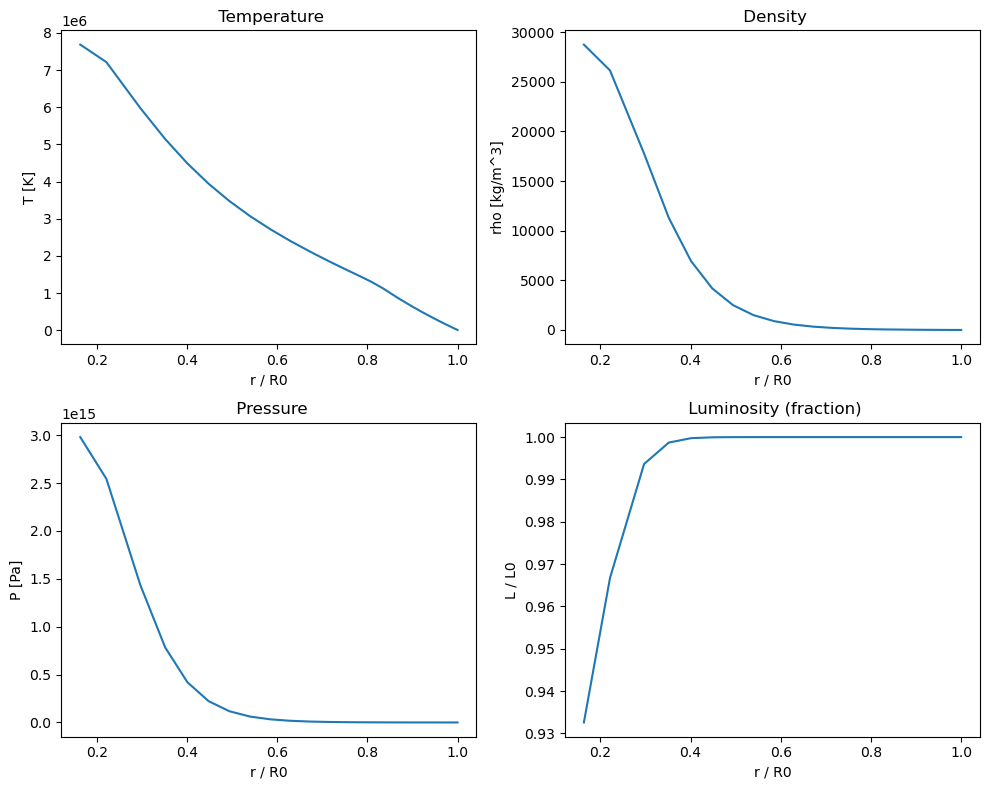

WARNING [opacity]: log10(R)=2.017 outside [-8.0, 1.0]. Extrapolating.
WARNING [opacity]: log10(R)=2.017 outside [-8.0, 1.0]. Extrapolating.
WARNING [opacity]: log10(R)=2.017 outside [-8.0, 1.0]. Extrapolating.
WARNING [opacity]: log10(R)=2.017 outside [-8.0, 1.0]. Extrapolating.
WARNING [opacity]: log10(R)=2.017 outside [-8.0, 1.0]. Extrapolating.
WARNING [opacity]: log10(R)=2.017 outside [-8.0, 1.0]. Extrapolating.
WARNING [opacity]: log10(R)=2.015 outside [-8.0, 1.0]. Extrapolating.
WARNING [opacity]: log10(R)=1.992 outside [-8.0, 1.0]. Extrapolating.
WARNING [opacity]: log10(R)=1.834 outside [-8.0, 1.0]. Extrapolating.
WARNING [opacity]: log10(R)=1.668 outside [-8.0, 1.0]. Extrapolating.
WARNING [opacity]: log10(R)=1.505 outside [-8.0, 1.0]. Extrapolating.
WARNING [opacity]: log10(R)=1.344 outside [-8.0, 1.0]. Extrapolating.
WARNING [opacity]: log10(R)=1.183 outside [-8.0, 1.0]. Extrapolating.
WARNING [opacity]: log10(R)=1.023 outside [-8.0, 1.0]. Extrapolating.


C:\Users\Shubham Apte\AppData\Local\Temp\ipykernel_18200\3792993726.py:112: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  surface_circle = plt.Circle((0, 0), 1.0, color="none",


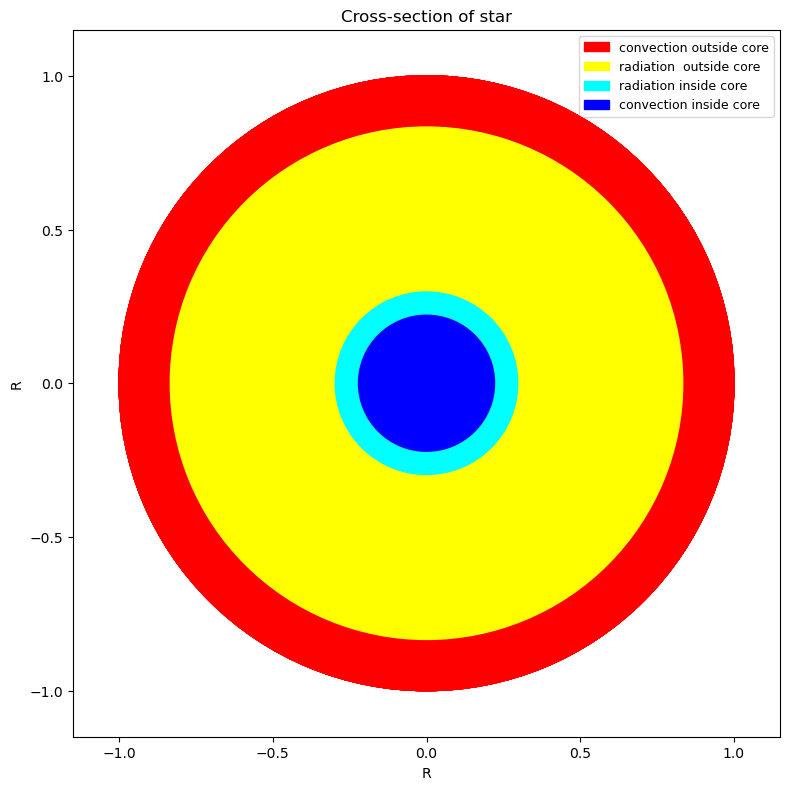

In [104]:

#  Task 7 plots


def evaluate_model(m_arr, r_arr, L_arr, R0, L0, M0,conv_mask, core_mask):
    """
    Compute diagnostic numbers for Task 7:
      - central fractions of m, r, L
      - core radius fraction
      - convective envelope width near surface
    """
    
    m_c = m_arr[-1]  # inner most point = last (integrated inward)
    r_c = r_arr[-1]
    L_c = L_arr[-1]
    m_frac = m_c / M0
    r_frac = r_c / R0
    L_frac = L_c / L0

    if np.any(core_mask):
        r_core_edge = np.max(r_arr[core_mask])  # core radius=outer boundary of core mask
        core_radius_frac = r_core_edge / R0
    else:
        core_radius_frac = np.nan


    
    conv_at_surface = conv_mask
    i = 0                                                     # i= 0= surface, i= n = center
    while i < len(conv_at_surface) and conv_at_surface[i] == True: # continue until reaching 1st radiative layer
        i += 1
    if i > 0:
        
        r_outer = r_arr[0] # surface radius
        r_inner = r_arr[i-1]  # last convective layer
        conv_width_frac = (r_outer - r_inner) / R0  # width of convective envelope near surface
    else:
        conv_width_frac = 0.0

    diagnostics = {"m_c_frac": m_frac,"r_c_frac": r_frac,"L_c_frac": L_frac,"core_radius_frac": core_radius_frac,"conv_width_frac": conv_width_frac}

    return diagnostics


def print_diagnostics(diag): 

    print(" Model diagnostics")
    print(f"m_c / M0        = {diag['m_c_frac']:.3e}")
    print(f"r_c / R0        = {diag['r_c_frac']:.3e}")
    print(f"L_c / L0        = {diag['L_c_frac']:.3e}")
    print(f"core radius/R0  = {diag['core_radius_frac']:.3f}")
    print(f"conv. width/R0  = {diag['conv_width_frac']:.3f}")
    print()


def plot_profiles(m_arr, r_arr, P_arr, L_arr, T_arr, rho_arr,R0, L0, M0, title_prefix=""): 
    """
    Plot main radial profiles T(r), rho(r), P(r), L(r) vs r/R0.
    """
    r_frac = r_arr / R0

    fig, axs = plt.subplots(2, 2, figsize=(10, 8))

    ax = axs[0, 0]
    ax.plot(r_frac, T_arr)
    ax.set_xlabel("r / R0")
    ax.set_ylabel("T [K]")
    ax.set_title(f"{title_prefix} Temperature")

    ax = axs[0, 1]
    ax.plot(r_frac, rho_arr)
    ax.set_xlabel("r / R0")
    ax.set_ylabel("rho [kg/m^3]")
    ax.set_title(f"{title_prefix} Density")

    ax = axs[1, 0]
    ax.plot(r_frac, P_arr)
    ax.set_xlabel("r / R0")
    ax.set_ylabel("P [Pa]")
    ax.set_title(f"{title_prefix} Pressure")

    ax = axs[1, 1]
    ax.plot(r_frac, L_arr / L0)
    ax.set_xlabel("r / R0")
    ax.set_ylabel("L / L0")
    ax.set_title(f"{title_prefix} Luminosity (fraction)")

    plt.tight_layout()
    plt.show()


def run_model_with_factors(R0_factor=1.0,T0_factor=1.0,rho0_factor=1.0,L0_factor=1.0,m_min_fraction=1e-4,rtol=1e-4,atol=1e-8,r_stop=1e3): 
    """
    
    Run a model with scaled initial parameters and print diagnostics+ plots.

    Parameters are factors relative to the "solar" surface values.
    """
    # solar values
    M0 = M_sun
    R0 = R0_factor * R_sun
    L0 = L0_factor * L_sun
    rho_bar = 1.408e3
    rho0_base = 1.42e-7 * rho_bar
    rho0 = rho0_factor * rho0_base
    T0_base = 5770.0
    T0 = T0_factor * T0_base

    print("Running model with factors ")
    print(f"R0_factor   = {R0_factor}")
    print(f"T0_factor   = {T0_factor}")
    print(f"rho0_factor = {rho0_factor}")
    print(f"L0_factor   = {L0_factor}")
    print()

    m_arr, r_arr, P_arr, L_arr, T_arr, rho_arr = integrate_structure(M0=M0, R0=R0,L0=L0,T0=T0,rho0=rho0,mu=mu,m_min_fraction=m_min_fraction,r_stop=r_stop,rtol=rtol,atol=atol)

    print("Integration finished.")
    print("Number of points:", len(m_arr))
    print("Centre-like values (last point):")
    print("m   =", m_arr[-1], "kg")
    print("r   =", r_arr[-1], "m")
    print("P   =", P_arr[-1], "Pa")
    print("L   =", L_arr[-1], "W")
    print("T   =", T_arr[-1], "K")
    print("rho =", rho_arr[-1], "kg/m^3")
    print()

    # Classify zones for diagnostics and cross-section
    core_mask, conv_mask = classify_zones(m_arr, r_arr, P_arr, L_arr, T_arr, rho_arr, L0)

    # Diagnostics
    diag = evaluate_model(m_arr, r_arr, L_arr, R0, L0, M0, conv_mask, core_mask)
    print_diagnostics(diag)

    # Plots
    plot_profiles(m_arr, r_arr, P_arr, L_arr, T_arr, rho_arr,R0, L0, M0, title_prefix="")
    plot_cross_section_2D(m_arr, r_arr, P_arr, L_arr, T_arr, rho_arr,L0=L0, R0=R0, title="Cross-section of star")

    return m_arr, r_arr, P_arr, L_arr, T_arr, rho_arr, diag



if __name__ == "__main__":
    run_sanity_checks()

    # Run a model with default solar initial conditions and make plots
    m_arr, r_arr, P_arr, L_arr, T_arr, rho_arr, diag = run_model_with_factors(R0_factor=1.0,T0_factor=1.0,rho0_factor=100.0,L0_factor=0.3,m_min_fraction=1e-4,rtol=1e-4,atol=1e-8,r_stop=1e3)

# temperature gradient plot

WARNING [opacity]: log10(R)=2.017 outside [-8.0, 1.0]. Extrapolating.
WARNING [opacity]: log10(R)=2.017 outside [-8.0, 1.0]. Extrapolating.
WARNING [opacity]: log10(R)=2.017 outside [-8.0, 1.0]. Extrapolating.
WARNING [opacity]: log10(R)=2.017 outside [-8.0, 1.0]. Extrapolating.
WARNING [opacity]: log10(R)=2.017 outside [-8.0, 1.0]. Extrapolating.
WARNING [opacity]: log10(R)=2.017 outside [-8.0, 1.0]. Extrapolating.
WARNING [opacity]: log10(R)=2.017 outside [-8.0, 1.0]. Extrapolating.
WARNING [opacity]: log10(R)=2.017 outside [-8.0, 1.0]. Extrapolating.
WARNING [opacity]: log10(R)=2.017 outside [-8.0, 1.0]. Extrapolating.
WARNING [opacity]: log10(R)=2.017 outside [-8.0, 1.0]. Extrapolating.
WARNING [opacity]: log10(R)=2.017 outside [-8.0, 1.0]. Extrapolating.
WARNING [opacity]: log10(R)=2.017 outside [-8.0, 1.0]. Extrapolating.
WARNING [opacity]: log10(R)=2.017 outside [-8.0, 1.0]. Extrapolating.
WARNING [opacity]: log10(R)=2.017 outside [-8.0, 1.0]. Extrapolating.
WARNING [opacity]: l

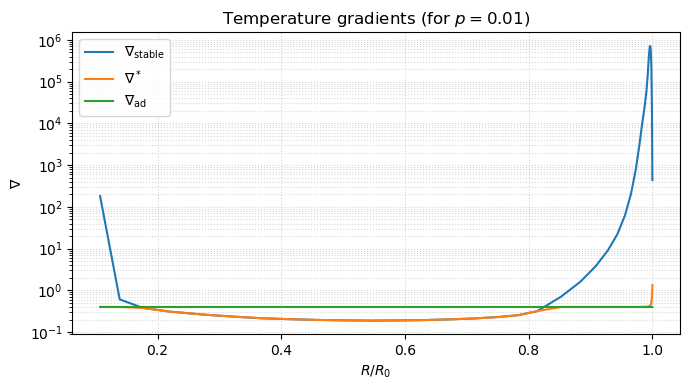

In [105]:
def compute_temperature_gradients(m_arr, r_arr, P_arr, L_arr, T_arr, rho_arr):  
    """
    Compute nabla_stable, nabla_ad, nabla_star.

    Returns
    -------
    nab_stable_arr : array
    nab_ad_arr     : array
    nab_star_arr   : array 
    """
    N = len(r_arr)
    nab_stable_arr = np.zeros(N)
    nab_ad_arr     = np.zeros(N)
    nab_star_arr   = np.zeros(N)

    C_p = cp_ideal(mu)

    for i in range(N):
        r   = r_arr[i]
        P   = P_arr[i]
        L   = L_arr[i]
        T   = T_arr[i]
        rho = rho_arr[i]
        m   = m_arr[i]

        r_safe = max(r, 1e-30) # avoid r=0

        g   = G * m / r_safe**2
        H_p = pressure_scale_height(P, rho, g, T)
        kappa = get_opacity(T, rho)

        nab_st = nabla_stable(kappa, rho, H_p, L, r_safe, T)
        nab_ad_val = nabla_ad(P, T, rho, C_p)

        nab_stable_arr[i] = nab_st
        nab_ad_arr[i]     = nab_ad_val

        if nab_st <= nab_ad_val:
            # radiative = use nabla_stable
            nab_star_arr[i] = nab_st
        else:
            # convective = compute and use nabla_star
            nab_star_arr[i] = nabla_convective(kappa, rho, H_p, L, r_safe, T, P)

    return nab_stable_arr, nab_ad_arr, nab_star_arr


def plot_temperature_gradients(m_arr, r_arr, P_arr, L_arr, T_arr, rho_arr,R0, title="Temperature gradients (for p = 0.01)"):
    """
    Make a log-y plot of nabla_stable, nabla_star, nabla_ad vs r/R0.
    """
    nab_stable_arr, nab_ad_arr, nab_star_arr = compute_temperature_gradients(m_arr, r_arr, P_arr, L_arr, T_arr, rho_arr)

    r_frac = r_arr / R0

    fig, ax = plt.subplots(figsize=(7, 4))

    ax.semilogy(r_frac, nab_stable_arr, label=r"$\nabla_\mathrm{stable}$")
    ax.semilogy(r_frac, nab_star_arr,   label=r"$\nabla^*$")
    ax.semilogy(r_frac, nab_ad_arr,     label=r"$\nabla_\mathrm{ad}$")

    ax.set_xlabel(r"$R / R_0$")
    ax.set_ylabel(r"$\nabla$")
    ax.set_title(title)

    ax.legend()
    ax.grid(True, which="both", ls=":", alpha=0.5)

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":

    M0 = M_sun
    R0 = 0.8 * R_sun    
    L0 = 0.8 * L_sun     

    rho_bar = 1.408e3
    rho0_base = 1.42e-7 * rho_bar
    rho0 = 100.0 * rho0_base    

    T0_base = 5770.0
    T0 = T0_base                

    m_arr, r_arr, P_arr, L_arr, T_arr, rho_arr = integrate_structure(
        M0=M0,
        R0=R0,
        L0=L0,
        T0=T0,
        rho0=rho0,
        mu=mu,
        m_min_fraction=1e-4,
        r_stop=1e3,
        rtol=1e-4,
        atol=1e-8,
    )

    plot_temperature_gradients(
        m_arr, r_arr, P_arr, L_arr, T_arr, rho_arr,
        R0=R0,
        title=r"Temperature gradients (for $p = 0.01$)"
    )